We estimate $L = \mathbb{E}[(\theta - f(Y))^2]$ two ways:

$$\hat{L}^{MC} = \frac{1}{N}\sum_{i=1}^{N}(\theta^{(i)} - f(Y^{(i)}))^2 \qquad \theta \sim \pi$$

$$\hat{L}^{IS} = \frac{1}{N}\sum_{i=1}^{N} w(\theta^{(i)})\,(\theta^{(i)} - f(Y^{(i)}))^2 \qquad \theta \sim q_\alpha$$

If $\text{Var}(\hat{L}^{IS}) > \text{Var}(\hat{L}^{MC})$, the IS weights are adding more noise than the boundary concentration removes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import torch
import torch.nn as nn

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')            
print(f"Using device: {device}")

Using device: cpu


In [9]:
A = 5.0
T = 64
ALPHA_VALUES = [1.5, 1.0, 0.7, 0.5, 0.3, 0.1]
BETA_SIGMA = 1

N_EPOCHS = 48
N_BATCHES = 48
BATCH_SIZE = 64

K = 500   # independent loss estimates per alpha
N = 128   # samples per estimate

In [10]:
def sample_from_proposal(batch_size, alpha_rho, alpha_sigma, beta_sigma, A, device='cpu'):
    rho_tilde = np.random.beta(alpha_rho, alpha_rho, size=batch_size)
    sigma_tilde = np.random.beta(alpha_sigma, beta_sigma, size=batch_size)
    rho = torch.tensor(2 * rho_tilde - 1, dtype=torch.float32, device=device)
    sigma = torch.tensor(A * sigma_tilde, dtype=torch.float32, device=device)
    return rho, sigma

def compute_importance_weights(rho, sigma, alpha_rho, alpha_sigma, beta_sigma, A):
    if torch.is_tensor(rho):
        rho = rho.cpu().numpy()
        sigma = sigma.cpu().numpy()
    rho_tilde = (rho + 1) / 2
    sigma_tilde = sigma / A
    q_rho = stats.beta.pdf(rho_tilde, alpha_rho, alpha_rho) / 2
    q_sigma = stats.beta.pdf(sigma_tilde, alpha_sigma, beta_sigma) / A
    p_theta = 1.0 / (2 * A)
    return p_theta / (q_rho * q_sigma)

def simulate_ar1_batch(rho, sigma, T, batch_size, device='cpu'):
    eps = torch.randn(batch_size, T, device=device) * sigma[:, None]
    rho_safe = torch.clamp(rho, -0.999999, 0.999999)
    x0 = torch.randn(batch_size, device=device) * sigma / torch.sqrt(1 - rho_safe**2 + 1e-8)
    x = torch.zeros(batch_size, T, device=device)
    x[:, 0] = rho * x0 + eps[:, 0]
    for t in range(1, T):
        x[:, t] = rho * x[:, t-1] + eps[:, t]
    return x

class GRUPosteriorEstimator(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=64, num_layers=2, mlp_hidden=128):
        super().__init__()
        self.gru = nn.GRU(input_size=input_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, batch_first=True)
        self.mlp = nn.Sequential(
            nn.Linear(hidden_dim, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, mlp_hidden), nn.ReLU(),
            nn.Linear(mlp_hidden, 32), nn.ReLU(),
            nn.Linear(32, 2))
    def forward(self, x):
        x = x.unsqueeze(-1)
        gru_out, _ = self.gru(x)
        pooled = gru_out.mean(dim=1)
        raw = self.mlp(pooled)
        rho = torch.tanh(raw[:, 0])
        sigma = torch.exp(raw[:, 1])
        return torch.stack([rho, sigma], dim=1)

print("Functions loaded!")

Functions loaded!


In [11]:
# Train one reference model with uniform sampling
np.random.seed(42)
torch.manual_seed(42)

model = GRUPosteriorEstimator().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)

print("Training reference model...")
for epoch in range(N_EPOCHS):
    model.train()
    for _ in range(N_BATCHES):
        rho = torch.empty(BATCH_SIZE, device=device).uniform_(-1, 1)
        sigma = torch.empty(BATCH_SIZE, device=device).uniform_(0, A)
        x = simulate_ar1_batch(rho, sigma, T, BATCH_SIZE, device=device)
        if torch.isnan(x).any(): continue

        pred = model(x)
        loss = ((pred - torch.stack([rho, sigma], dim=1))**2).mean()

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

    if (epoch + 1) % 16 == 0:
        print(f"  Epoch {epoch+1}/{N_EPOCHS}, loss = {loss.item():.4f}")

model.eval()
print("Done!")

Training reference model...
  Epoch 16/48, loss = 0.0641
  Epoch 32/48, loss = 0.0615
  Epoch 48/48, loss = 0.1270
Done!


In [12]:
# Variance experiment: K independent loss estimates per proposal
# For each alpha, draw K batches and compute the raw IS loss estimate
np.random.seed(0)

loss_estimates = {}

for alpha in ALPHA_VALUES:
    estimates = []
    for k in range(K):
        rho, sigma = sample_from_proposal(N, alpha, alpha, BETA_SIGMA, A, device=device)
        w = compute_importance_weights(rho, sigma, alpha, alpha, BETA_SIGMA, A)
        w = torch.tensor(w, dtype=torch.float32, device=device)

        x = simulate_ar1_batch(rho, sigma, T, N, device=device)
        with torch.no_grad():
            pred = model(x)
        per_sample_loss = ((pred - torch.stack([rho, sigma], dim=1))**2).sum(dim=1) # MSE per sample

        # Raw IS estimate: (1/N) * sum(w * loss)
        estimates.append((w * per_sample_loss).mean().item())

    loss_estimates[alpha] = np.array(estimates)

# Print results
mc_var = loss_estimates[1.0].var()
print(f"{'Alpha':<10} {'Mean':<12} {'Std':<12} {'Var Ratio':<12}")
print("-"*46)
for alpha in ALPHA_VALUES:
    est = loss_estimates[alpha]
    ratio = est.var() / mc_var
    print(f"a={alpha:<8} {est.mean():<12.4f} {est.std():<12.4f} {ratio:<12.2f}")

Alpha      Mean         Std          Var Ratio   
----------------------------------------------
a=1.5      0.1330       0.0475       4.80        
a=1.0      0.1346       0.0217       1.00        
a=0.7      0.1326       0.0226       1.08        
a=0.5      0.1307       0.0292       1.81        
a=0.3      0.1366       0.0478       4.85        
a=0.1      0.1370       0.1220       31.58       


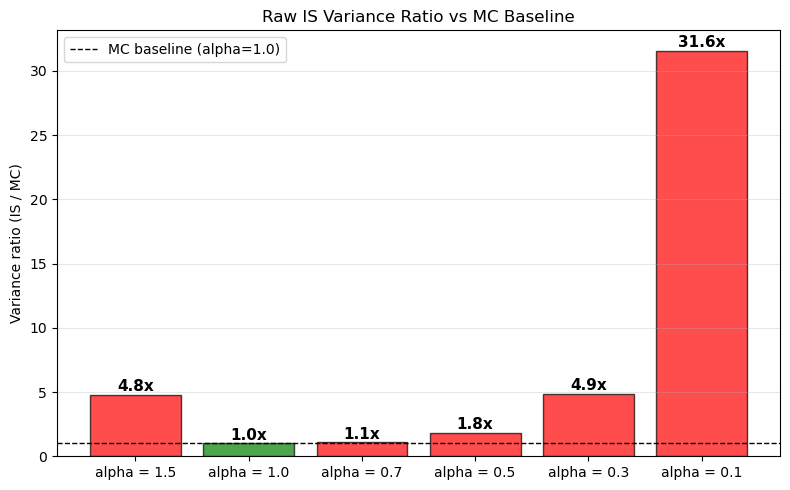

In [13]:
# Variance ratio bar chart
variances = [loss_estimates[a].var() for a in ALPHA_VALUES]
mc_var = variances[1]
ratios = [v / mc_var for v in variances]

colors = ['green' if r <= 1.0 else 'red' for r in ratios]
x_pos = np.arange(len(ALPHA_VALUES))

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(x_pos, ratios, color=colors, alpha=0.7, edgecolor='black')
ax.axhline(y=1.0, color='black', linestyle='--', linewidth=1, label='MC baseline (alpha=1.0)')

for bar, r in zip(bars, ratios):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{r:.1f}x', ha='center', fontsize=11, fontweight='bold')

ax.set_xticks(x_pos)
ax.set_xticklabels([f'alpha = {a}' for a in ALPHA_VALUES])
ax.set_ylabel('Variance ratio (IS / MC)')
ax.set_title('Raw IS Variance Ratio vs MC Baseline')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()